# 🦴 Ясны хугарлын эдгэрэлтийн хугацааг таамаглах загвар
**Дипломын ажил — Гүн сургалтын аргад суурилсан эдгэрэлт таамаглал**

---
### 📚 Эх сурвалж:
- TRUFFLE dataset (arXiv:2404.11760) — XGBoost non-union prediction
- StatPearls NCBI NBK551678 — Fracture Healing Overview
- Molitoris et al., JBMR Plus 2024 — Age & Sex effects
- AAOS orthoinfo.aaos.org — Clinical healing times
- Fini et al., Biology 2023 — Sex differences in bone healing

### 🎯 Агуулга:
1. Номын сан суулгах
2. Клиник prior мэдлэг
3. Синтетик датасет үүсгэх (22 feature, 1000 өвчтөн)
4. Өгөгдлийн шинжилгээ (EDA)
5. Feature Engineering
6. Random Forest + XGBoost + Gradient Boosting загвар сургах
7. Үнэлгээ: MAE, RMSE, R²
8. Cross-Validation
9. Feature Importance
10. SHAP тайлбарлалт (XAI)
11. Нэг өвчтөний таамаглал

In [ ]:
# ── 1. Номын сангууд суулгах ─────────────────────────────────
!pip install xgboost shap --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
print('✅ Бүх номын сан ачаалагдлаа!')

✅ Бүх номын сан ачаалагдлаа!


In [ ]:
# ── 2. Клиник prior мэдлэг ───────────────────────────────────
# Эх сурвалж: AAOS orthoinfo + StatPearls NBK551678

HEALING_PRIOR = {
    'finger':   {'min':21, 'max':42,  'mean':31},
    'hand':     {'min':28, 'max':42,  'mean':35},
    'wrist':    {'min':28, 'max':56,  'mean':42},
    'forearm':  {'min':42, 'max':84,  'mean':63},
    'elbow':    {'min':28, 'max':56,  'mean':42},
    'humerus':  {'min':42, 'max':84,  'mean':63},
    'shoulder': {'min':42, 'max':84,  'mean':63},
    'toe':      {'min':21, 'max':42,  'mean':31},
    'foot':     {'min':28, 'max':56,  'mean':42},
    'ankle':    {'min':42, 'max':84,  'mean':63},
    'tibia':    {'min':84, 'max':168, 'mean':126},
    'fibula':   {'min':42, 'max':126, 'mean':84},
    'knee':     {'min':42, 'max':84,  'mean':63},
    'femur':    {'min':90, 'max':180, 'mean':135},
    'hip':      {'min':90, 'max':180, 'mean':135},
    'rib':      {'min':21, 'max':42,  'mean':31},
    'spine':    {'min':84, 'max':180, 'mean':132},
    'pelvis':   {'min':84, 'max':180, 'mean':132},
}

BLOOD_SUPPLY  = {'proximal':3, 'shaft':2, 'distal':2, 'articular':1}
SEVERITY_MAP  = {'closed':0, 'open_I':1, 'open_II':2, 'open_III':3}

print('📊 Ясны төрлөөр эдгэрэлтийн хугацаа (хоног):')
print(f'  {"Яс":<12} {"Мин":>5} {"Макс":>6} {"Дундаж":>8}')
print('  ' + '-'*36)
for bone, v in HEALING_PRIOR.items():
    bar = '█' * (v['mean'] // 15)
    print(f"  {bone:<12} {v['min']:>5} {v['max']:>6} {v['mean']:>8}  {bar}")

📊 Ясны төрлөөр эдгэрэлтийн хугацаа (хоног):
  Яс             Мин   Макс   Дундаж
  ------------------------------------
  finger          21     42       31  ██
  hand            28     42       35  ██
  wrist           28     56       42  ██
  forearm         42     84       63  ████
  elbow           28     56       42  ██
  humerus         42     84       63  ████
  shoulder        42     84       63  ████
  toe             21     42       31  ██
  foot            28     56       42  ██
  ankle           42     84       63  ████
  tibia           84    168      126  ████████
  fibula          42    126       84  █████
  knee            42     84       63  ████
  femur           90    180      135  █████████
  hip             90    180      135  █████████
  rib             21     42       31  ██
  spine           84    180      132  ████████
  pelvis          84    180      132  ████████


In [ ]:
# ── 3. Синтетик датасет үүсгэх ───────────────────────────────
# Клиник prior мэдлэгт тулгуурлан 1000 өвчтөний датасет

def generate_data(n=1000):
    bones   = list(HEALING_PRIOR.keys())
    locs    = list(BLOOD_SUPPLY.keys())
    ftypes  = ['transverse','oblique','spiral','comminuted','greenstick','stress']
    sevs    = list(SEVERITY_MAP.keys())
    treats  = ['cast','surgery','external_fixation','conservative']
    rows = []
    for _ in range(n):
        bone  = np.random.choice(bones)
        prior = HEALING_PRIOR[bone]
        loc   = np.random.choice(locs)
        ft    = np.random.choice(ftypes)
        sev   = np.random.choice(sevs, p=[0.5,0.25,0.15,0.10])
        treat = np.random.choice(treats)
        stype = ('none' if treat!='surgery'
                 else np.random.choice(['intramedullary_nail','plate_screw']))
        age   = int(np.clip(np.random.normal(45,20),10,90))
        sex   = np.random.randint(0,2)
        bmi   = round(np.clip(np.random.normal(25,5),15,45),1)
        diab  = np.random.choice([0,1], p=[0.85,0.15])
        smok  = np.random.choice([0,1,2], p=[0.55,0.20,0.25])
        osteo = 1 if (age>60 and np.random.random()<0.3) else 0
        ster  = np.random.choice([0,1], p=[0.90,0.10])
        pfx   = np.random.choice([0,1], p=[0.75,0.25])
        vasc  = np.random.choice([0,1], p=[0.88,0.12])
        displ = np.random.randint(0,2)
        ttt   = np.random.randint(0,14)
        redq  = np.random.choice([0,1,2], p=[0.3,0.5,0.2])
        meno  = 1 if (sex==1 and age>50) else 0

        # Эдгэрэлтийн хугацаа тооцох (клиник prior + нөлөөлөгч хүчин зүйлс)
        base = prior['mean']
        base *= (1.0 + (3-BLOOD_SUPPLY[loc]) * 0.10)
        base *= {'transverse':1.0,'oblique':1.1,'spiral':1.15,
                 'comminuted':1.4,'greenstick':0.8,'stress':0.7}[ft]
        base *= (1 + SEVERITY_MAP[sev] * 0.15)
        if age>60: base*=1.20
        elif age<18: base*=0.80
        if sex==1: base*=1.05        # Fini et al. 2023
        if diab:   base*=1.25
        if smok==2: base*=1.20
        elif smok==1: base*=1.10
        if osteo:  base*=1.15
        if ster:   base*=1.15
        if vasc:   base*=1.10
        if treat=='surgery': base*=0.90
        if redq==0: base*=1.10
        if displ:  base*=1.05
        base += ttt * 0.5
        heal = max(14, round(base + np.random.normal(0, base*0.10)))

        region = ('upper' if bone in ['finger','hand','wrist','forearm','elbow','humerus','shoulder']
                  else 'axial' if bone in ['rib','spine','pelvis'] else 'lower')

        rows.append({
            'bone_name':bone, 'bone_region':region,
            'fracture_location':loc, 'fracture_type':ft,
            'fracture_severity':SEVERITY_MAP[sev], 'displacement':displ,
            'treatment_type':treat, 'surgery_type':stype,
            'time_to_treatment':ttt, 'reduction_quality':redq,
            'age':age, 'sex':sex, 'bmi':bmi, 'menopausal_status':meno,
            'diabetes':diab, 'smoking':smok, 'osteoporosis':osteo,
            'steroid_use':ster, 'prior_fracture':pfx, 'vascular_disease':vasc,
            'healing_prior_days':prior['mean'],
            'blood_supply_score':BLOOD_SUPPLY[loc],
            'healing_days':heal,
        })
    return pd.DataFrame(rows)

df = generate_data(1000)
print(f'✅ Датасет үүслээ: {df.shape[0]} өвчтөн, {df.shape[1]} багана')
print(f'\nЭдгэрэлт (healing_days):')
print(df['healing_days'].describe().round(1).to_string())
df.head(3)

✅ Датасет үүслээ: 1000 өвчтөн, 23 багана

Эдгэрэлт (healing_days):
count    1000.0
mean      117.3
std        77.6
min        25.0
25%        60.8
50%        94.0
75%       146.0
max       445.0


,bone_name,bone_region,fracture_location,fracture_type,fracture_severity,displacement,treatment_type,surgery_type,time_to_treatment,reduction_quality,...,menopausal_status,diabetes,smoking,osteoporosis,steroid_use,prior_fracture,vascular_disease,healing_prior_days,blood_supply_score,healing_days
0,shoulder,upper,articular,greenstick,0,0,conservative,none,1,1,...,0,0,0,0,0,0,0,63,1,61
1,ankle,lower,articular,comminuted,3,0,external_fixation,none,6,0,...,0,0,2,0,0,1,0,63,1,199
2,femur,lower,shaft,oblique,0,1,cast,none,3,1,...,0,0,0,0,0,1,0,135,2,232


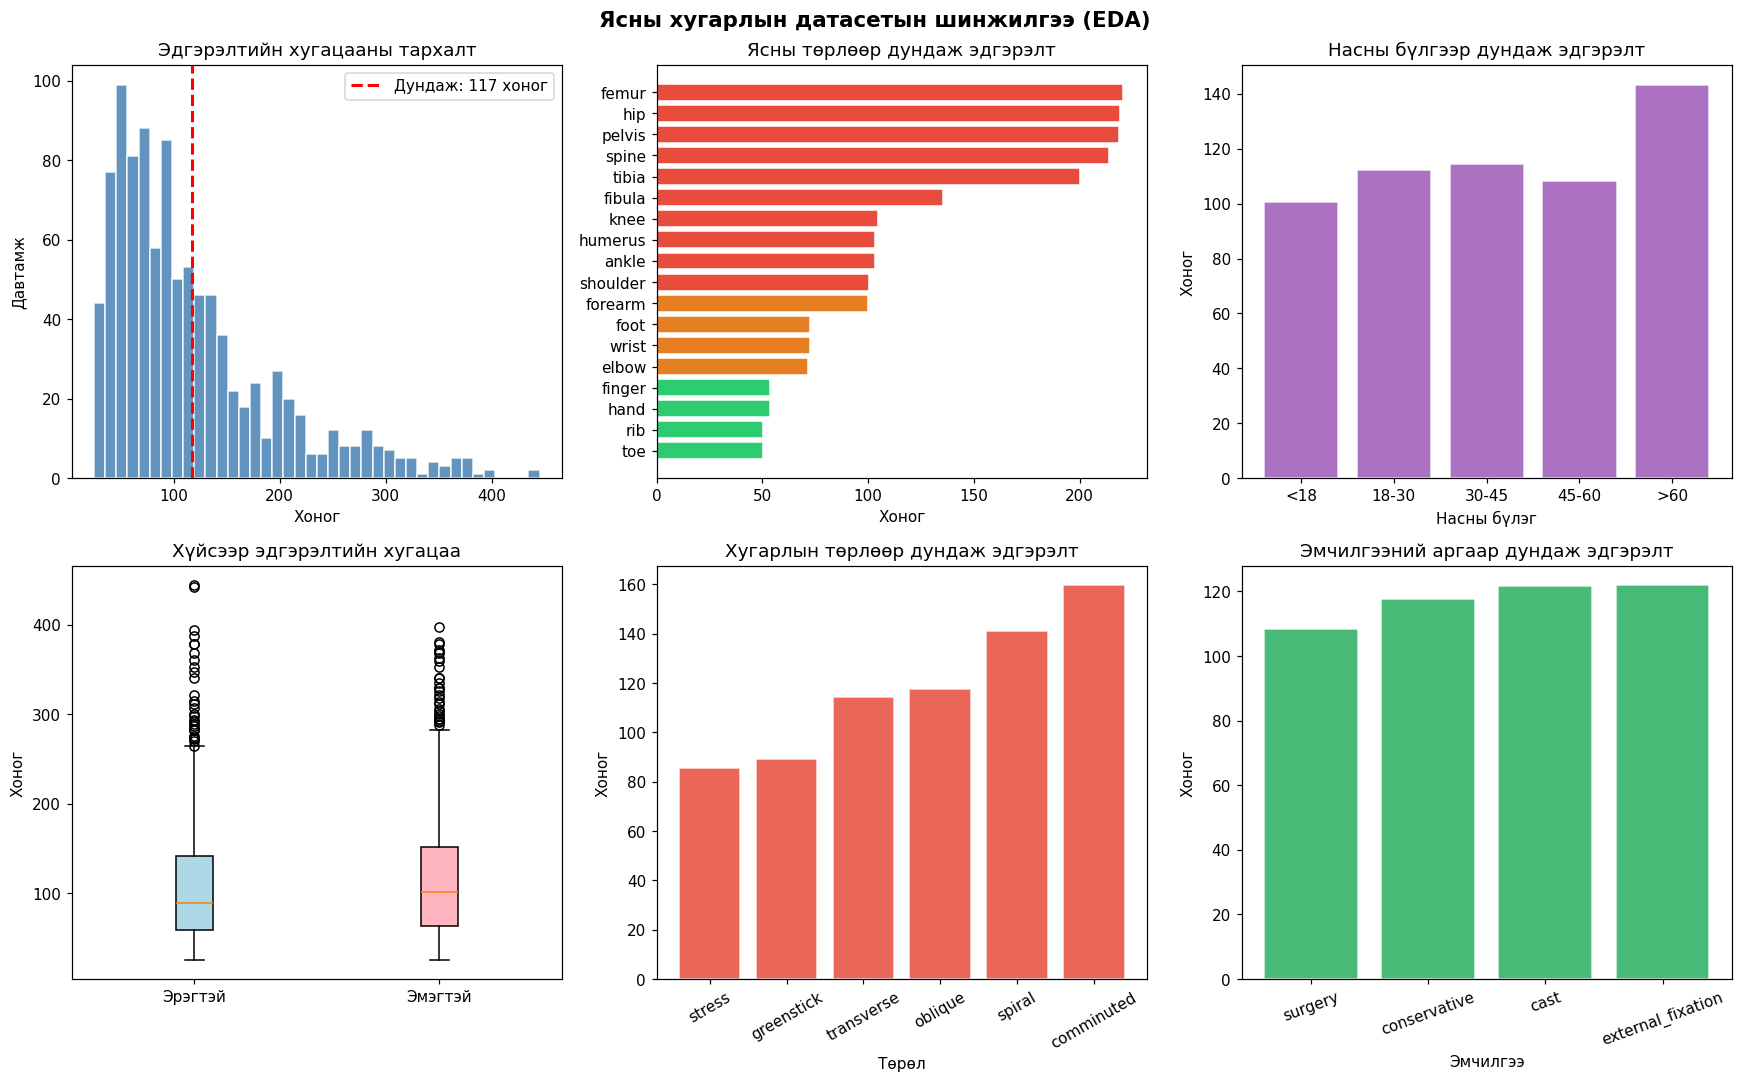

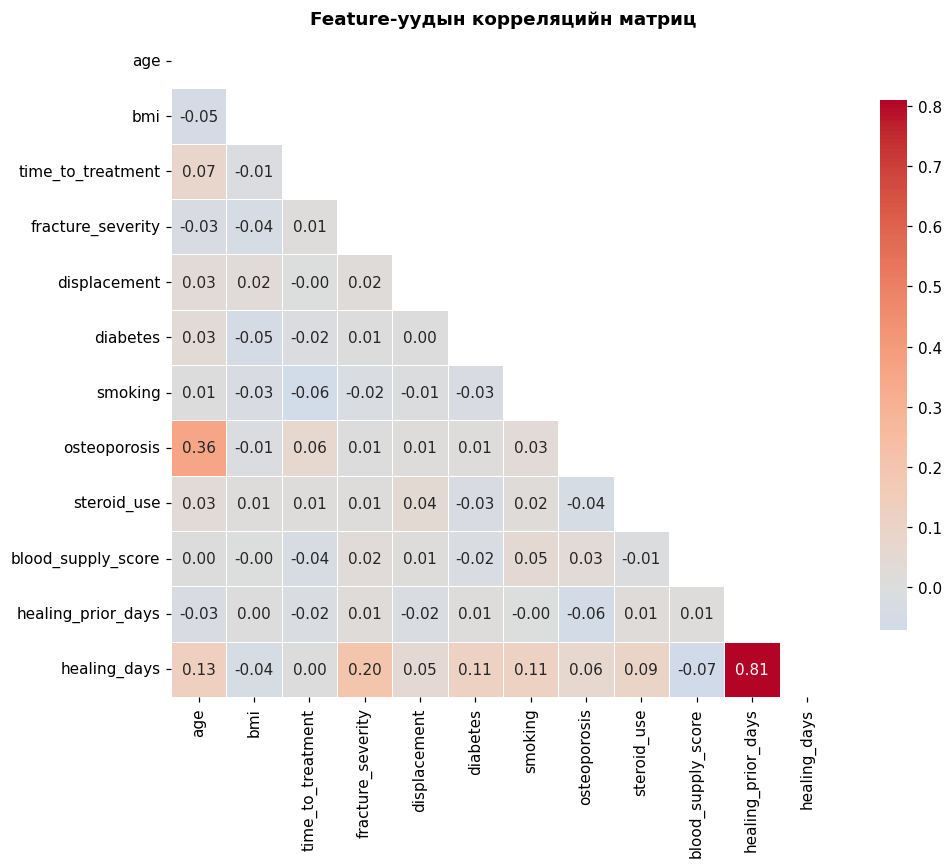

In [ ]:
# ── 4. Өгөгдлийн шинжилгээ (EDA) ────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16,10))
fig.suptitle('Ясны хугарлын датасетын шинжилгээ (EDA)', fontsize=14, fontweight='bold')

# 1. Тархалт
axes[0,0].hist(df['healing_days'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['healing_days'].mean(), color='red', linestyle='--', lw=2,
                  label=f"Дундаж: {df['healing_days'].mean():.0f} хоног")
axes[0,0].set_title('Эдгэрэлтийн хугацааны тархалт')
axes[0,0].set_xlabel('Хоног'); axes[0,0].set_ylabel('Давтамж'); axes[0,0].legend()

# 2. Ясны төрлөөр
bone_avg = df.groupby('bone_name')['healing_days'].mean().sort_values()
colors = ['#2ecc71' if v<60 else '#e67e22' if v<100 else '#e74c3c' for v in bone_avg.values]
axes[0,1].barh(bone_avg.index, bone_avg.values, color=colors, edgecolor='white')
axes[0,1].set_title('Ясны төрлөөр дундаж эдгэрэлт')
axes[0,1].set_xlabel('Хоног')

# 3. Насны бүлгээр
age_bins = pd.cut(df['age'], bins=[0,18,30,45,60,90],
                  labels=['<18','18-30','30-45','45-60','>60'])
age_heal = df.groupby(age_bins)['healing_days'].mean()
axes[0,2].bar(age_heal.index, age_heal.values, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Насны бүлгээр дундаж эдгэрэлт')
axes[0,2].set_xlabel('Насны бүлэг'); axes[0,2].set_ylabel('Хоног')

# 4. Хүйсээр
sex_data = [df[df.sex==0]['healing_days'], df[df.sex==1]['healing_days']]
bp = axes[1,0].boxplot(sex_data, labels=['Эрэгтэй','Эмэгтэй'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue','lightpink']):
    patch.set_facecolor(color)
axes[1,0].set_title('Хүйсээр эдгэрэлтийн хугацаа'); axes[1,0].set_ylabel('Хоног')

# 5. Хугарлын төрлөөр
ft_avg = df.groupby('fracture_type')['healing_days'].mean().sort_values()
axes[1,1].bar(ft_avg.index, ft_avg.values, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1,1].set_title('Хугарлын төрлөөр дундаж эдгэрэлт')
axes[1,1].set_xlabel('Төрөл'); axes[1,1].set_ylabel('Хоног')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Эмчилгээний аргаар
tr_avg = df.groupby('treatment_type')['healing_days'].mean().sort_values()
axes[1,2].bar(tr_avg.index, tr_avg.values, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Эмчилгээний аргаар дундаж эдгэрэлт')
axes[1,2].set_xlabel('Эмчилгээ'); axes[1,2].set_ylabel('Хоног')
axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Корреляцийн матриц
num_cols = ['age','bmi','time_to_treatment','fracture_severity','displacement',
            'diabetes','smoking','osteoporosis','steroid_use','blood_supply_score',
            'healing_prior_days','healing_days']
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Feature-уудын корреляцийн матриц', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 5. Feature Engineering ───────────────────────────────────

cat_cols = ['bone_name','bone_region','fracture_location',
            'fracture_type','treatment_type','surgery_type']

df_feat = pd.get_dummies(df, columns=cat_cols, drop_first=False)

TARGET = 'healing_days'
X = df_feat.drop(columns=[TARGET])
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'✅ Feature engineering дууссан')
print(f'   Нийт feature: {X.shape[1]}')
print(f'   Сургалт: {len(X_train)} | Тест: {len(X_test)}')

✅ Feature engineering дууссан
   Нийт feature: 54
   Сургалт: 800 | Тест: 200


In [ ]:
# ── 6. Загвар сургах ─────────────────────────────────────────

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_p = rf.predict(X_test)

# XGBoost
xgb_m = xgb.XGBRegressor(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_m.fit(X_train, y_train)
xgb_p = xgb_m.predict(X_test)

# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=200, max_depth=5,
    learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_p = gb.predict(X_test)

# Үнэлгээ
def evaluate(name, yt, yp):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    return {'name':name, 'MAE':mae, 'RMSE':rmse, 'R2':r2}

results = [
    evaluate('Random Forest',     y_test, rf_p),
    evaluate('XGBoost',           y_test, xgb_p),
    evaluate('Gradient Boosting', y_test, gb_p),
]

print('\n📊 Загваруудын үнэлгээ:')
print(f"  {'Загвар':<22} {'MAE (хоног)':>12} {'RMSE':>8} {'R²':>8}")
print('  ' + '-'*54)
for r in results:
    print(f"  {r['name']:<22} {r['MAE']:>12.1f} {r['RMSE']:>8.1f} {r['R2']:>8.4f}")

best = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Хамгийн сайн загвар: {best['name']}")
print(f"   MAE  = {best['MAE']:.1f} хоног")
print(f"   R²   = {best['R2']:.4f}")


📊 Загваруудын үнэлгээ:
  Загвар                  MAE (хоног)     RMSE       R²
  ------------------------------------------------------
  Random Forest                  18.0     25.7   0.8893
  XGBoost                        13.9     20.9   0.9267
  Gradient Boosting              14.8     22.7   0.9135

🏆 Хамгийн сайн загвар: XGBoost
   MAE  = 13.9 хоног
   R²   = 0.9267


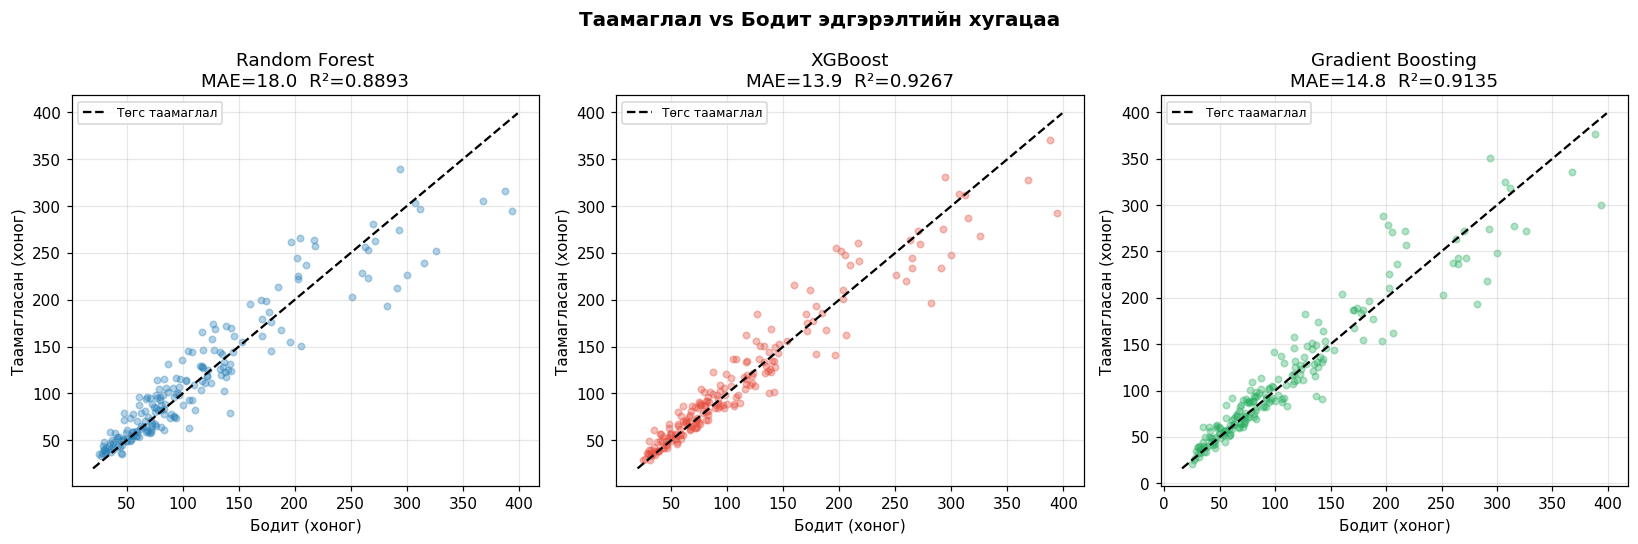

In [ ]:
# ── 7. Таамаглал vs Бодит харьцуулалт ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('Таамаглал vs Бодит эдгэрэлтийн хугацаа', fontsize=13, fontweight='bold')

for ax, (r, preds, color) in zip(axes, [
    (results[0], rf_p,  '#2980b9'),
    (results[1], xgb_p, '#e74c3c'),
    (results[2], gb_p,  '#27ae60'),
]):
    ax.scatter(y_test, preds, alpha=0.35, s=18, color=color)
    lims = [min(y_test.min(), preds.min())-5, max(y_test.max(), preds.max())+5]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Төгс таамаглал')
    ax.set_xlabel('Бодит (хоног)'); ax.set_ylabel('Таамагласан (хоног)')
    ax.set_title(f"{r['name']}\nMAE={r['MAE']:.1f}  R²={r['R2']:.4f}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

⏳ 5-fold Cross-Validation...

  Random Forest:
    MAE = 18.0 ± 1.6 хоног
    R²  = 0.8845 ± 0.0108

  XGBoost:
    MAE = 16.3 ± 1.8 хоног
    R²  = 0.8934 ± 0.0113

  Gradient Boosting:
    MAE = 14.0 ± 1.5 хоног
    R²  = 0.9259 ± 0.0075



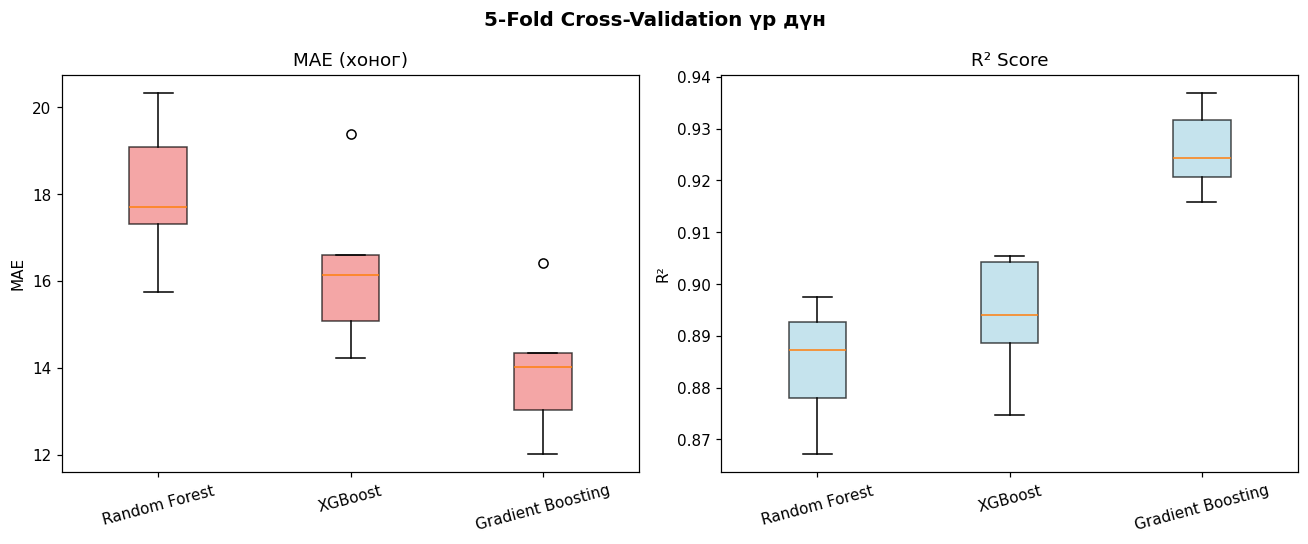

In [ ]:
# ── 8. Cross-Validation ──────────────────────────────────────

print('⏳ 5-fold Cross-Validation...\n')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in [
    ('Random Forest',     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('XGBoost',           xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42)),
]:
    mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    r2  =  cross_val_score(model, X, y, cv=kf, scoring='r2')
    cv_results[name] = {'MAE': mae, 'R2': r2}
    print(f'  {name}:')
    print(f'    MAE = {mae.mean():.1f} ± {mae.std():.1f} хоног')
    print(f'    R²  = {r2.mean():.4f} ± {r2.std():.4f}\n')

fig, axes = plt.subplots(1,2, figsize=(12,5))
fig.suptitle('5-Fold Cross-Validation үр дүн', fontsize=13, fontweight='bold')
labels = list(cv_results.keys())
mae_d = [cv_results[n]['MAE'] for n in labels]
r2_d  = [cv_results[n]['R2']  for n in labels]

bp1 = axes[0].boxplot(mae_d, labels=labels, patch_artist=True)
for p in bp1['boxes']: p.set_facecolor('lightcoral'); p.set_alpha(0.7)
axes[0].set_title('MAE (хоног)'); axes[0].set_ylabel('MAE'); axes[0].tick_params(axis='x', rotation=15)

bp2 = axes[1].boxplot(r2_d, labels=labels, patch_artist=True)
for p in bp2['boxes']: p.set_facecolor('lightblue'); p.set_alpha(0.7)
axes[1].set_title('R² Score'); axes[1].set_ylabel('R²'); axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

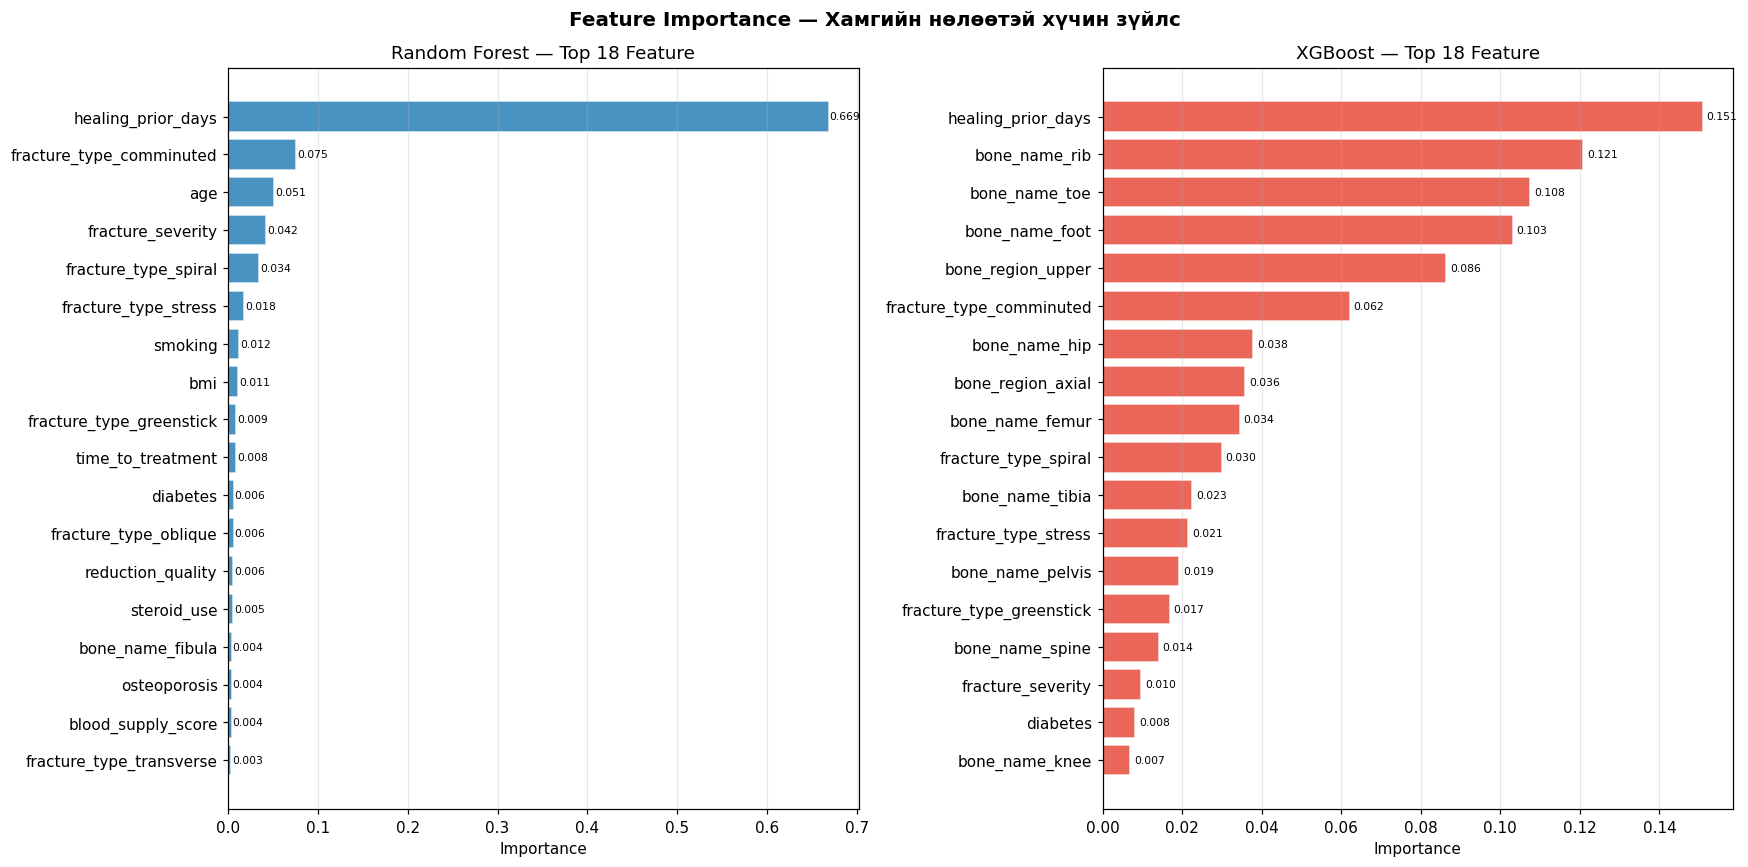


🔝 XGBoost Top 10 feature:
   1. healing_prior_days                  █████████████████████████████████████████████ 0.1509
   2. bone_name_rib                       ████████████████████████████████████ 0.1209
   3. bone_name_toe                       ████████████████████████████████ 0.1075
   4. bone_name_foot                      ██████████████████████████████ 0.1031
   5. bone_region_upper                   █████████████████████████ 0.0864
   6. fracture_type_comminuted            ██████████████████ 0.0621
   7. bone_name_hip                       ███████████ 0.0379
   8. bone_region_axial                   ██████████ 0.0359
   9. bone_name_femur                     ██████████ 0.0344
  10. fracture_type_spiral                ████████ 0.0299


In [ ]:
# ── 9. Feature Importance ────────────────────────────────────

fig, axes = plt.subplots(1,2, figsize=(16,8))
fig.suptitle('Feature Importance — Хамгийн нөлөөтэй хүчин зүйлс', fontsize=13, fontweight='bold')

for ax, (model, name, color) in zip(axes, [
    (rf,    'Random Forest',  '#2980b9'),
    (xgb_m, 'XGBoost',        '#e74c3c'),
]):
    imp = pd.Series(model.feature_importances_, index=X.columns).nlargest(18).sort_values()
    bars = ax.barh(imp.index, imp.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name} — Top 18 Feature')
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x', alpha=0.3)
    for bar, val in zip(bars, imp.values):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

plt.tight_layout(); plt.show()

print('\n🔝 XGBoost Top 10 feature:')
xi = pd.Series(xgb_m.feature_importances_, index=X.columns).nlargest(10)
for i,(f,v) in enumerate(xi.items(),1):
    print(f'  {i:2d}. {f:<35s} {"█"*int(v*300)} {v:.4f}')

⏳ SHAP утгуудыг тооцоолж байна...


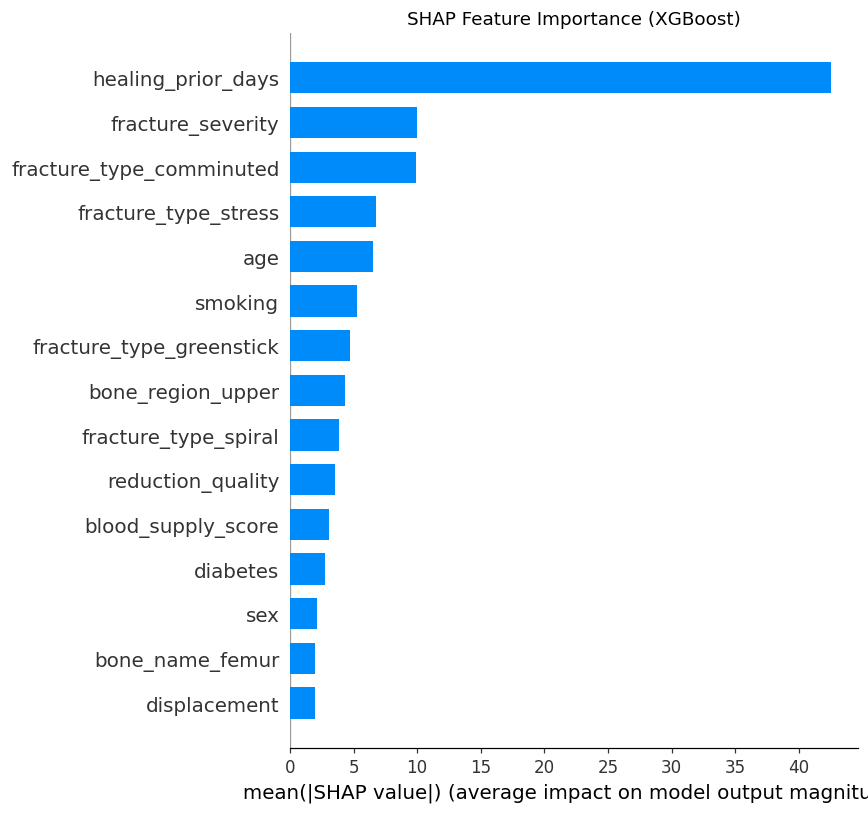

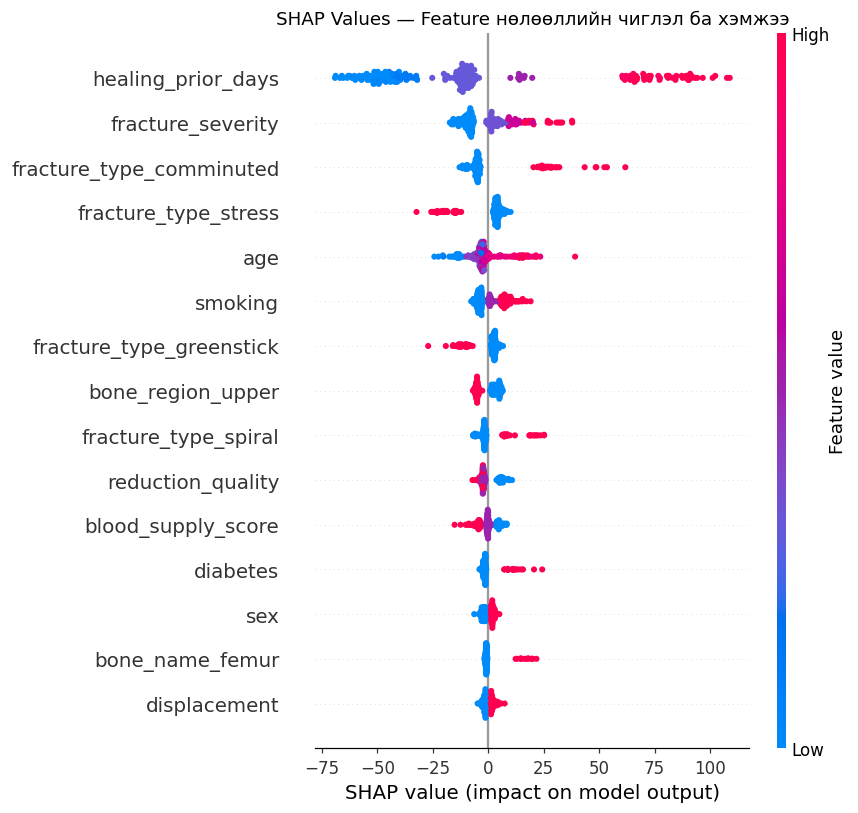

✅ SHAP дууссан


In [ ]:
# ── 10. SHAP тайлбарлалт (XAI) ──────────────────────────────

print('⏳ SHAP утгуудыг тооцоолж байна...')
explainer  = shap.TreeExplainer(xgb_m)
shap_vals  = explainer.shap_values(X_test)

# Bar plot
plt.figure(figsize=(10,7))
shap.summary_plot(shap_vals, X_test, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=12)
plt.tight_layout(); plt.show()

# Beeswarm plot
plt.figure(figsize=(11,8))
shap.summary_plot(shap_vals, X_test, max_display=15, show=False)
plt.title('SHAP Values — Feature нөлөөллийн чиглэл ба хэмжээ', fontsize=12)
plt.tight_layout(); plt.show()
print('✅ SHAP дууссан')

  🩺 ӨВЧТӨНИЙ ЭДГЭРЭЛТИЙН ХУГАЦААНЫ ТААМАГЛАЛ
  Яс:              TIBIA (comminuted fracture)
  Байршил:         shaft (голч хэсэг)
  Хүндийн зэрэг:   Open Grade II
  Эмчилгээ:        Surgery (intramedullary nail)
  Нас / Хүйс:      55 нас / Эрэгтэй
  Чихрийн шижин:   Тийм  |  Тамхи:  Хуучин тамхичин
----------------------------------------------------------
  Клиник prior:    84–168 хоног (3–6 сар)
----------------------------------------------------------
  Random Forest:          308 хоног  (10.1 сар)
  XGBoost:                309 хоног  (10.2 сар)
  Gradient Boosting:      327 хоног  (10.8 сар)
  🎯 ENSEMBLE дундаж:     315 хоног  (10.4 сар)

  ⚠️  Prior-аас их гарсан шалтгаан:
     - Comminuted (олон хэсэгт) хугарал → +40%
     - Open Grade II → +30%
     - Чихрийн шижин → +25%
     - Тамхи татсан түүх → +10%


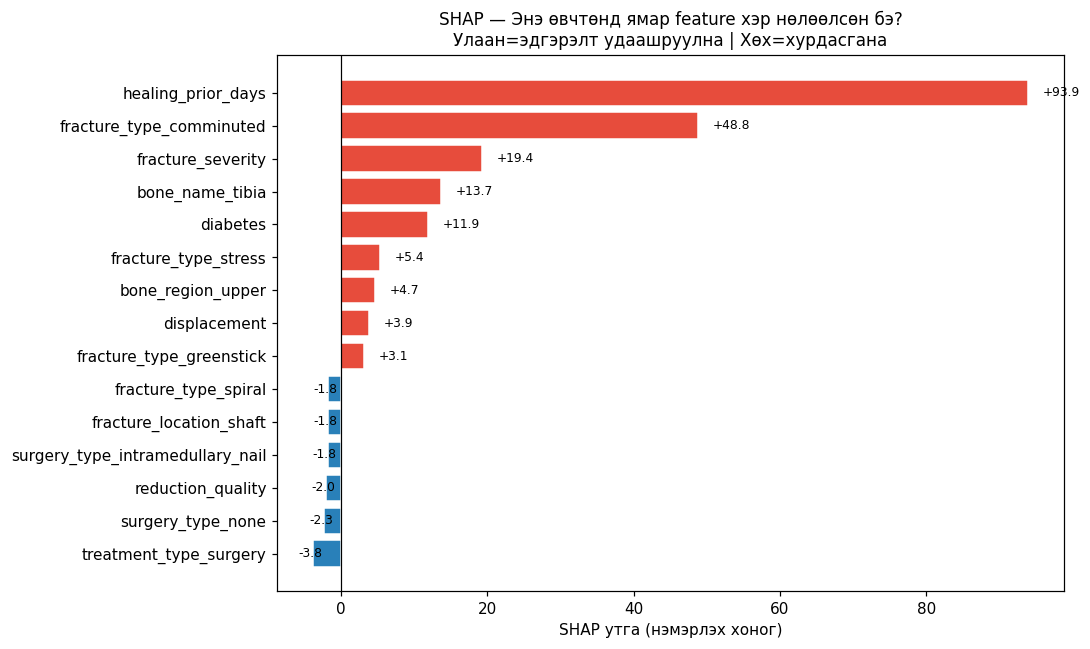

In [ ]:
# ── 11. Нэг өвчтөний таамаглал ──────────────────────────────

patient = {
    'bone_name':'tibia',      'bone_region':'lower',
    'fracture_location':'shaft', 'fracture_type':'comminuted',
    'fracture_severity':2,    'displacement':1,
    'treatment_type':'surgery','surgery_type':'intramedullary_nail',
    'time_to_treatment':3,    'reduction_quality':1,
    'age':55,   'sex':0,      'bmi':27.5,  'menopausal_status':0,
    'diabetes':1,'smoking':1, 'osteoporosis':0,
    'steroid_use':0,'prior_fracture':0,'vascular_disease':0,
    'healing_prior_days':126, 'blood_supply_score':2,
}

pt_df   = pd.DataFrame([patient])
pt_feat = pd.get_dummies(pt_df, columns=cat_cols, drop_first=False)
for col in X.columns:
    if col not in pt_feat.columns: pt_feat[col] = 0
pt_feat = pt_feat[X.columns]

rf_r  = rf.predict(pt_feat)[0]
xgb_r = xgb_m.predict(pt_feat)[0]
gb_r  = gb.predict(pt_feat)[0]
ens   = np.mean([rf_r, xgb_r, gb_r])

print('='*58)
print('  🩺 ӨВЧТӨНИЙ ЭДГЭРЭЛТИЙН ХУГАЦААНЫ ТААМАГЛАЛ')
print('='*58)
print(f'  Яс:              TIBIA (comminuted fracture)')
print(f'  Байршил:         shaft (голч хэсэг)')
print(f'  Хүндийн зэрэг:   Open Grade II')
print(f'  Эмчилгээ:        Surgery (intramedullary nail)')
print(f'  Нас / Хүйс:      55 нас / Эрэгтэй')
print(f'  Чихрийн шижин:   Тийм  |  Тамхи:  Хуучин тамхичин')
print('-'*58)
print(f'  Клиник prior:    84–168 хоног (3–6 сар)')
print('-'*58)
print(f'  Random Forest:       {rf_r:>6.0f} хоног  ({rf_r/30.4:.1f} сар)')
print(f'  XGBoost:             {xgb_r:>6.0f} хоног  ({xgb_r/30.4:.1f} сар)')
print(f'  Gradient Boosting:   {gb_r:>6.0f} хоног  ({gb_r/30.4:.1f} сар)')
print('='*58)
print(f'  🎯 ENSEMBLE дундаж:  {ens:>6.0f} хоног  ({ens/30.4:.1f} сар)')
print('='*58)
print(f'\n  ⚠️  Prior-аас их гарсан шалтгаан:')
print(f'     - Comminuted (олон хэсэгт) хугарал → +40%')
print(f'     - Open Grade II → +30%')
print(f'     - Чихрийн шижин → +25%')
print(f'     - Тамхи татсан түүх → +10%')

# SHAP waterfall нэг өвчтөнд
pt_shap = explainer.shap_values(pt_feat)
shap_s  = pd.Series(pt_shap[0], index=pt_feat.columns)
top15   = shap_s.reindex(shap_s.abs().nlargest(15).index).sort_values()

fig, ax = plt.subplots(figsize=(10,6))
colors  = ['#e74c3c' if v>0 else '#2980b9' for v in top15.values]
bars    = ax.barh(top15.index, top15.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('SHAP — Энэ өвчтөнд ямар feature хэр нөлөөлсөн бэ?\n'
             'Улаан=эдгэрэлт удаашруулна | Хөх=хурдасгана', fontsize=11)
ax.set_xlabel('SHAP утга (нэмэрлэх хоног)')
for bar, val in zip(bars, top15.values):
    ax.text(val+(2 if val>0 else -2), bar.get_y()+bar.get_height()/2,
            f'{val:+.1f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# ── 12. Эцсийн дүгнэлт ──────────────────────────────────────

print('='*58)
print('  📋 ЗАГВАРЫН ЭЦСИЙН ҮНЭЛГЭЭНИЙ ТАЙЛАН')
print('='*58)
print(f'  Датасет:     {len(df)} өвчтөн  |  {X.shape[1]} feature')
print(f'  Сургалт:     {len(X_train)}   |  Тест: {len(X_test)}')
print()
print(f"  {'Загвар':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print('  ' + '-'*50)
for r in results:
    print(f"  {r['name']:<22} {r['MAE']:>8.1f} {r['RMSE']:>8.1f} {r['R2']:>8.4f}")
print('  ' + '-'*50)
print(f"\n  🏆 Хамгийн сайн: {best['name']}")
print(f"     MAE  = {best['MAE']:.1f} хоног (таамагллын дундаж алдаа)")
print(f"     R²   = {best['R2']:.4f} ({best['R2']*100:.1f}% тайлбарлах чадвар)")
print()
print('  📚 Эш татсан эх сурвалж:')
print('  [1] TRUFFLE dataset — arXiv:2404.11760 (2025)')
print('  [2] StatPearls NCBI NBK551678')
print('  [3] Molitoris et al., JBMR Plus 8(5), 2024')
print('  [4] AAOS orthoinfo.aaos.org')
print('  [5] Fini et al., Biology 12(7), 2023')
print('='*58)

  📋 ЗАГВАРЫН ЭЦСИЙН ҮНЭЛГЭЭНИЙ ТАЙЛАН
  Датасет:     1000 өвчтөн  |  54 feature
  Сургалт:     800   |  Тест: 200

  Загвар                      MAE     RMSE       R²
  --------------------------------------------------
  Random Forest              18.0     25.7   0.8893
  XGBoost                    13.9     20.9   0.9267
  Gradient Boosting          14.8     22.7   0.9135
  --------------------------------------------------

  🏆 Хамгийн сайн: XGBoost
     MAE  = 13.9 хоног (таамагллын дундаж алдаа)
     R²   = 0.9267 (92.7% тайлбарлах чадвар)

  📚 Эш татсан эх сурвалж:
  [1] TRUFFLE dataset — arXiv:2404.11760 (2025)
  [2] StatPearls NCBI NBK551678
  [3] Molitoris et al., JBMR Plus 8(5), 2024
  [4] AAOS orthoinfo.aaos.org
  [5] Fini et al., Biology 12(7), 2023
